In [2]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


In [4]:
data_folder = '/Users/benny/swc/agents/data/split_cost_results_260707'
solo_files = identify_filepaths.get_relative_paths('solo', data_folder)

In [5]:
len(solo_files)

45

In [6]:
df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

IntProgress(value=0, max=45)

filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_0/2026-06-25_22-38-05_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_1/2026-06-26_04-04-58_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_2/2026-06-26_09-30-23_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_4/2026-06-26_20-22-51_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_5/2026-06-27_01-51-03_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_6/2026-06-27_07-15-15_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_7/2026-06-27_12-44-07_solo.json
Loading complete.
Pr

In [7]:
dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

In [8]:
dropped_trials = 1
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 655
First trial end event found at index: 555
First trial end event found at index: 621
First trial end event found at index: 638
First trial end event found at index: 605
First trial end event found at index: 655
First trial end event found at index: 688
First trial end event found at index: 655
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at index: 671
First trial end event found at index: 605
First trial end event found at index: 2288
First trial end event found at index: 605
First trial end event found at index: 588
First trial end event found at index: 688
First trial end event found at index: 721
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 555
First trial end event found at index: 588
First trial end event found at index: 555
First trial end event found at index: 521
First trial end event found at in

In [9]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

In [10]:
import agent_analysis.functions.preprocessing as prep

_, step_penalties, thetas = prep.extract_step_penalties(data_folder, yaml_filename=None)
len(thetas)

No YAML file in excluded


45

## Session trajectories

In [11]:
# low translation / high turning first; high translation / low turning last
sorted_trials = sorted(
    zip(thetas, dfs_cropped),
    key=lambda x: x[0][0] / x[0][1] if x[0][1] != 0 else float("inf"),
    reverse=False
)

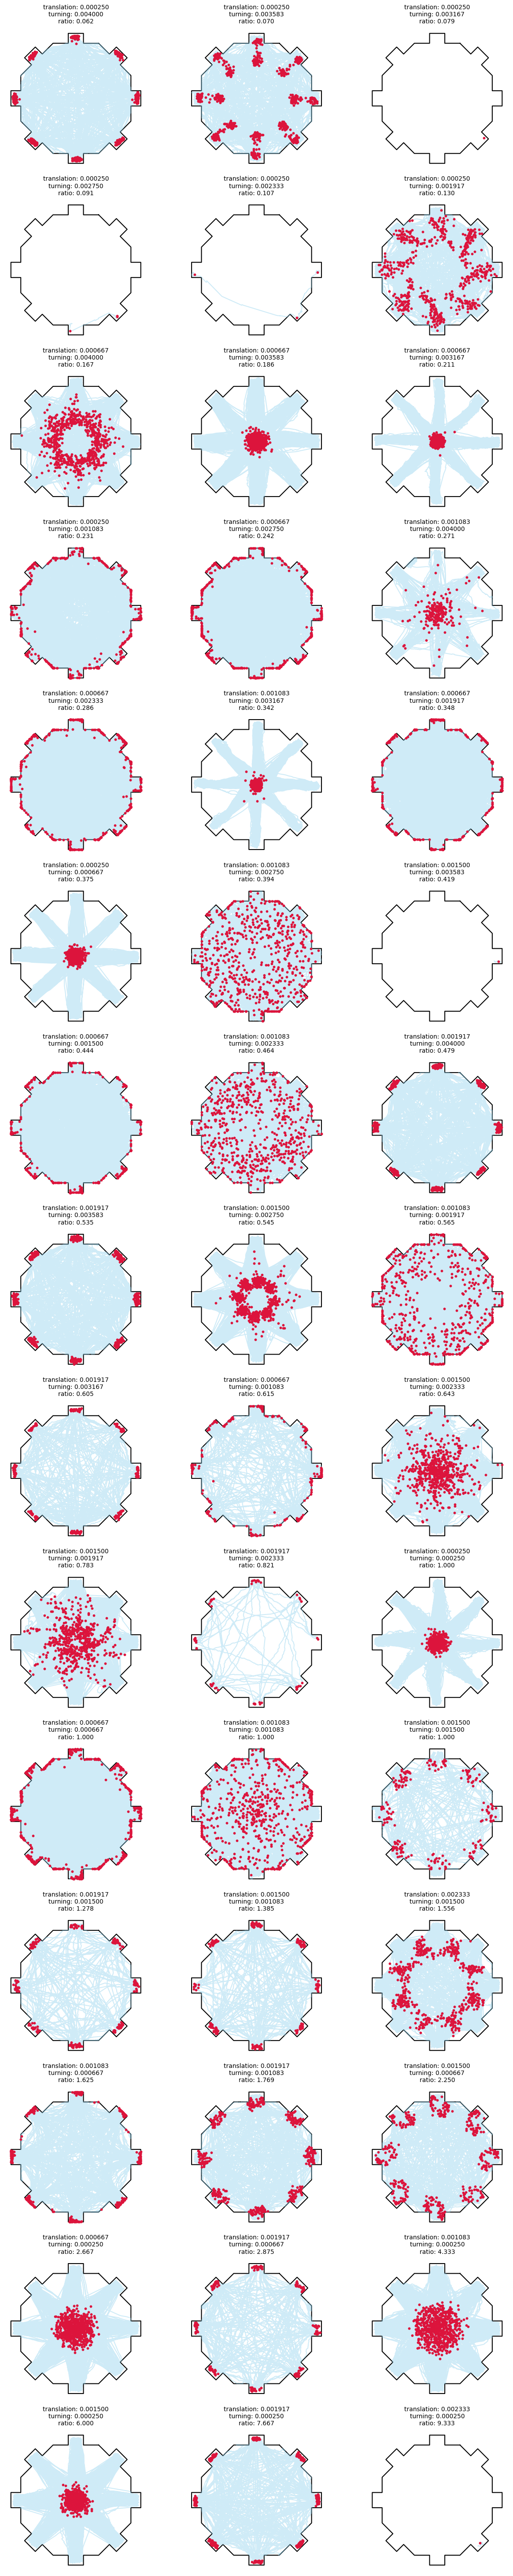

In [12]:
import matplotlib.pyplot as plt

num_lists = len(dfs_cropped)
num_cols = 3
num_rows = (num_lists + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))

axes = axes.flatten()

for i, (penalty, trial_list) in enumerate(sorted_trials):
    translation_cost, turning_cost = penalty
    ratio = translation_cost / turning_cost if turning_cost != 0 else float("inf")

    ax = plot_octagon.plot_octagon(ax=axes[i])
    plot_trajectory.plot_session_trajectory(
        ax,
        trial_list,
        colour_player_1='skyblue',
        alpha=0.4,
        slice_onset_markers=True
    )
    plot_trajectory.mark_session_slice_onsets(
        ax,
        trial_list,
        chosen_player=0,
        color='crimson'
    )

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(
        f'translation: {translation_cost:.6f}\n'
        f'turning: {turning_cost:.6f}\n'
        f'ratio: {ratio:.3f}',
        fontsize=10
    )

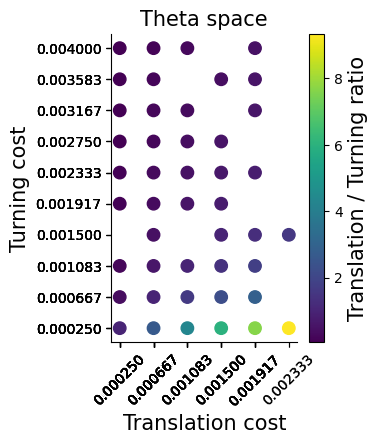

In [13]:
translation_costs = np.array([t[0] for t in thetas])
turning_costs = np.array([t[1] for t in thetas])
ratios = translation_costs / turning_costs

fig, ax = plt.subplots(figsize=(3, 4))

sc = ax.scatter(
    translation_costs,
    turning_costs,
    c=ratios,
    cmap="viridis",
    s=80
)

plt.colorbar(sc, ax=ax, label="Translation / Turning ratio")
# increase colorbar label size
plt.setp(plt.gcf().get_axes()[1].yaxis.label, fontsize=15)
# increase colorbar tick label size
# plt.setp(plt.gcf().get_axes()[1].tick_params(axis='y', labelsize=12))

#for i, (x, y) in enumerate(zip(translation_costs, turning_costs)):
#    ax.text(x, y, str(i), fontsize=8)

translation_costs = np.array([t[0] for t in thetas])
turning_costs = np.array([t[1] for t in thetas])

ax.tick_params(axis='x', rotation=45)

ax.set_xticks(translation_costs)
ax.set_yticks(turning_costs)

ax.set_xlabel("Translation cost", fontsize=15)
ax.set_ylabel("Turning cost", fontsize=15)
ax.set_title("Theta space", fontsize=15)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

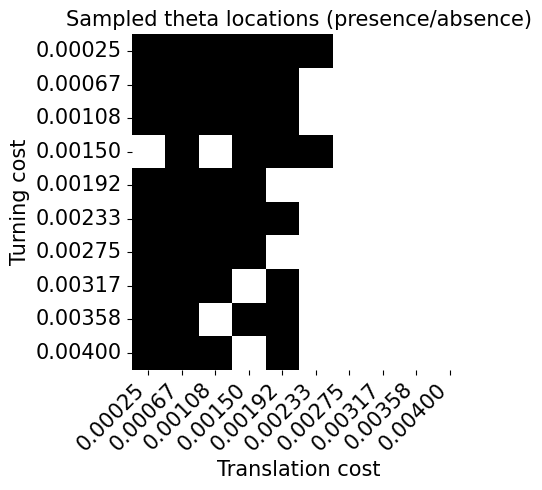

In [14]:
theta_df = pd.DataFrame({
    "translation": [t[0] for t in thetas],
    "turning": [t[1] for t in thetas],
})

# Define the full intended parameter range
translation_grid = np.linspace(0.00025, 0.004, 10)
turning_grid = np.linspace(0.00025, 0.004, 10)

# Count sampled thetas
count_table = theta_df.pivot_table(
    index="turning",
    columns="translation",
    aggfunc="size",
    fill_value=0
)

# Force heatmap to include unsampled grid locations
count_table = count_table.reindex(
    index=turning_grid,
    columns=translation_grid,
    fill_value=0
)

presence_table = count_table > 0

fig, ax = plt.subplots(figsize=(5, 5))

sns.heatmap(
    #count_table,
    presence_table,
    #cmap="viridis",
    cmap="Greys",

    square=True,
    ax=ax,
    #cbar_kws={"label": "Number of agents"},
    cbar=False
)

ax.set_xticklabels([f"{x:.5f}" for x in count_table.columns], rotation=45, ha="right", fontsize=15)
ax.set_yticklabels([f"{y:.5f}" for y in count_table.index], rotation=0, fontsize=15)

ax.set_xlabel("Translation cost", fontsize=15)
ax.set_ylabel("Turning cost", fontsize=15)
ax.set_title("Sampled theta locations (presence/absence)", fontsize=15)

plt.tight_layout()
plt.show()

## P(High) across models

In [15]:
# create empty dictionary

analysis_results = {
    session_id: {

            # trial list and filtered trial indices
            'trial_lists': {
                'full_session': None
            },

            # chosen wall numbers and whether high or low
            'choice_data' : {
                'wall_numbers': None,
                'chose_high': None,
                'probability_chose_high': None  # array of values from walls 1 to 8
            }
            

        }
    for session_id in np.arange(len(trial_lists))
}

In [16]:
# assign trial lists

for session_id in analysis_results.keys():

    print(f"\n\nProcessing session: {session_id}\n\n")
    player_data = analysis_results[session_id]
    trial_list = trial_lists[session_id]
    print(f"Number of trials in full session: {len(trial_list)}")


    player_data['trial_lists']['full_session'] = trial_list



Processing session: 0


Number of trials in full session: 718


Processing session: 1


Number of trials in full session: 726


Processing session: 2


Number of trials in full session: 721


Processing session: 3


Number of trials in full session: 657


Processing session: 4


Number of trials in full session: 223


Processing session: 5


Number of trials in full session: 605


Processing session: 6


Number of trials in full session: 599


Processing session: 7


Number of trials in full session: 604


Processing session: 8


Number of trials in full session: 596


Processing session: 9


Number of trials in full session: 725


Processing session: 10


Number of trials in full session: 720


Processing session: 11


Number of trials in full session: 698


Processing session: 12


Number of trials in full session: 528


Processing session: 13


Number of trials in full session: 700


Processing session: 14


Number of trials in full session: 541


Processing session: 15


Number o

In [17]:
# find chosen wall numbers and whether high or low

for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    trial_list = player_data['trial_lists']['full_session']

    player_data['choice_data']['wall_numbers'] = get_indices.get_chosen_walls(trial_list).astype(int)
    player_data['choice_data']['chose_high'] = get_indices.was_high_wall_chosen(trial_list)


    # print(len(player_data['choice_data']['chose_high']))

In [28]:
for session_id in analysis_results.keys():

    #print(session_id)
    
    player_data = analysis_results[session_id]
    wall_numbers = player_data['choice_data']['wall_numbers']
    chose_high = player_data['choice_data']['chose_high']

    #print(f"Wall numbers: {wall_numbers}")
    #print(f"Chose high: {chose_high}")

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    mask = counts > 4  # Ensure at least 5 trials per wall to calculate probability
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    player_data['choice_data']['probability_chose_high'] = wall_probabilities

    chose_high_total = len(chose_high[chose_high==True])
    session_len = len(player_data['trial_lists']['full_session'])
    if session_len > 0:
        p_high = chose_high_total/session_len
    else:
        p_high = np.nan
        
    player_data['choice_data']['p_high_model'] = p_high

In [30]:
# High translation / low turning first; low translation / high turning last
sorted_sessions = sorted(
    zip(thetas, analysis_results.keys()),
    key=lambda x: x[0][0] / x[0][1] if x[0][1] != 0 else float("inf"),
    reverse=True
)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_59010/1351886820.py:28: RuntimeWarning: Mean of empty slice
  avg_p_high = np.nanmean(wall_probabilities)


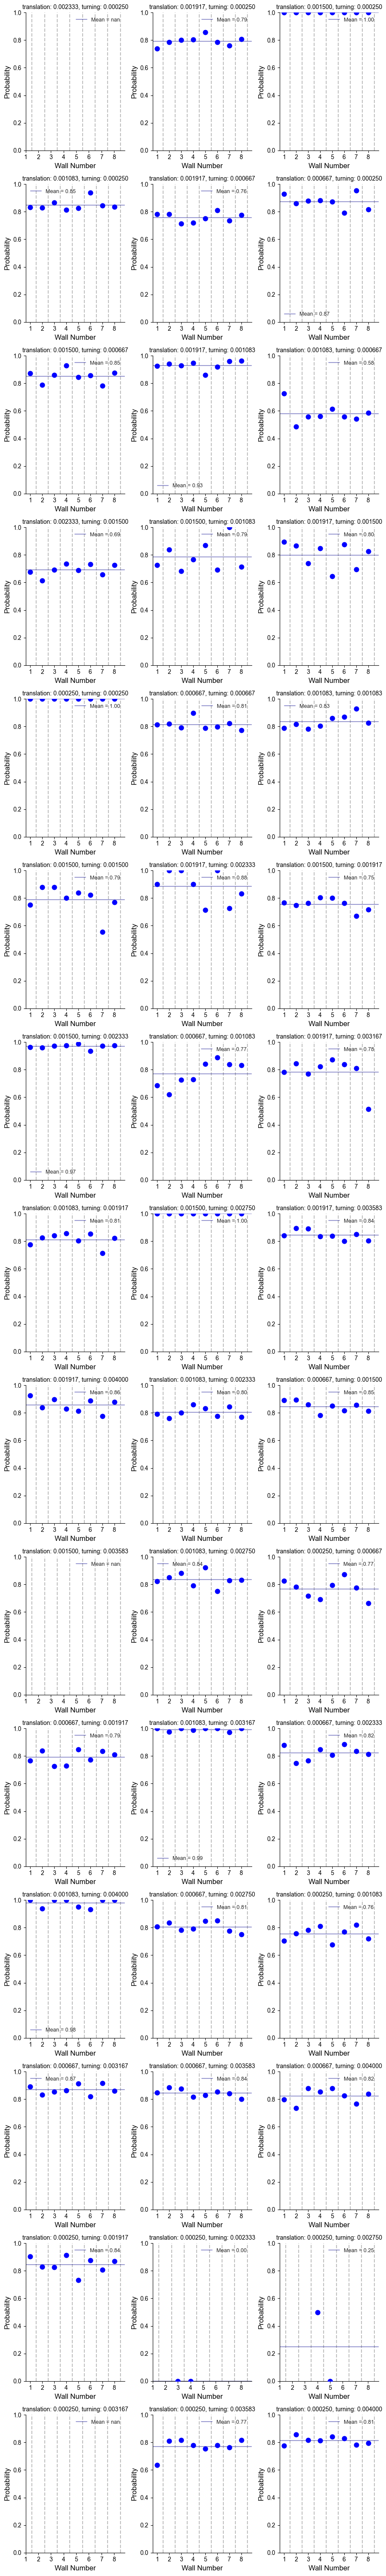

In [31]:
num_sessions = len(analysis_results)
num_cols = 3
num_rows = (num_sessions + num_cols - 1) // num_cols  # ceiling division
fig, axes = plt.subplots(num_rows, num_cols, figsize=(3*num_cols, 4*num_rows))

axes = axes.flatten()

for i, (theta, session_id) in enumerate(sorted_sessions):
    ax = axes[i]
    
    wall_number_list = [analysis_results[session_id]['choice_data']['wall_numbers']]
    chose_high_list = [analysis_results[session_id]['choice_data']['chose_high']]

    wall_numbers = np.concatenate(wall_number_list).astype(int)
    chose_high = np.concatenate(chose_high_list)

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    # Print average P(High) across walls for each session
    avg_p_high = np.nanmean(wall_probabilities)
    #print(f"Average P(High) for session {session_id} (translation, turning costs: {thetas[0]:.6f}, {thetas[1]:.6f}): {avg_p_high:.3f}")

    wall_numbers_plot = np.arange(1,9)
    
    # set seaborn style
    sns.set_style("white", {"axes.grid": False})

    # plot vertical dashed grey lines for each categorical x value
    for x in wall_numbers_plot:
        ax.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

    # plot individual wall probabilities
    ax.scatter(
        wall_numbers_plot,
        wall_probabilities,
        color="blue",
        s=60,
        zorder=3
    )

    # plot average probability as a horizontal line
    ax.axhline(
        avg_p_high,
        color="darkblue",
        linestyle="-",
        linewidth=1.5,
        alpha=0.4,
        label=f"Mean = {avg_p_high:.2f}"
    )

    ax.legend(frameon=False, fontsize=9)

    # Customize labels and title
    ax.set_xlabel("Wall Number", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)
    ax.set_title(f'translation: {theta[0]:.6f}, turning: {theta[1]:.6f}', fontsize=10)

    # set y-axis for probability
    ax.set_ylim([0,1])

    # adjust x-axis ticks to match categorical values
    ax.set_xticks(wall_numbers_plot)

    # Remove top and right borders
    sns.despine(ax=ax, top=True, right=True)

for j in range(num_sessions, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [32]:
translation_costs = []
turning_costs = []
avg_p_high_list = []
ratios = []

for theta, session_id in sorted_sessions:

    translation_costs.append(theta[0])
    turning_costs.append(theta[1])

    ratio = theta[0] / theta[1]   # translation / turning
    ratios.append(ratio)

    #wall_probabilities = analysis_results[session_id]['choice_data']['probability_chose_high']
    p_high_model = analysis_results[session_id]['choice_data']['p_high_model']

    avg_p_high_list.append(np.nanmean(p_high_model))

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_59010/2756432530.py:17: RuntimeWarning: Mean of empty slice
  avg_p_high_list.append(np.nanmean(p_high_model))


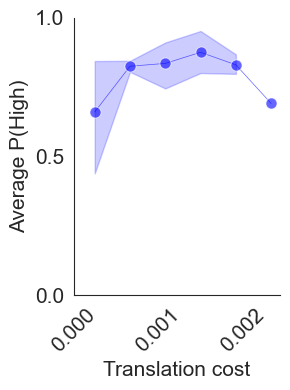

In [34]:
plt.figure(figsize=(3, 4))

sns.lineplot(
    x=translation_costs,
    y=avg_p_high_list,
    marker="o",
    linewidth=0.5,
    markersize=8,
    color="blue",
    alpha=0.6
)

plt.xticks(np.arange(0, max(translation_costs) + 0.0001, 0.001), fontsize=15, rotation=45)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=15)

plt.xlabel("Translation cost", fontsize=15)
plt.ylabel("Average P(High)", fontsize=15)

sns.despine()
plt.tight_layout()
plt.show()

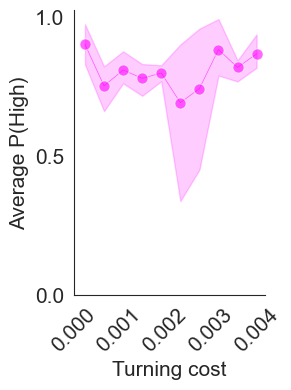

In [35]:
plt.figure(figsize=(3, 4))

sns.lineplot(
    x=turning_costs,
    y=avg_p_high_list,
    linewidth=0.5,
    marker="o",
    markersize=8,
    color="magenta",
    alpha=0.6
)

plt.xlabel("Turning cost", fontsize=15)
plt.ylabel("Average P(High)", fontsize=15)
plt.xticks(np.arange(0, max(turning_costs) + 0.0001, 0.001), fontsize=15, rotation=45)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=15)
sns.despine()
plt.tight_layout()
plt.show()

In [36]:
log_ratios = np.log(ratios)

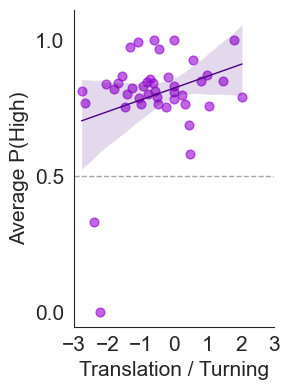

In [37]:
plt.figure(figsize=(3, 4))

sns.regplot(
    x=log_ratios,
    y=avg_p_high_list,
    scatter_kws={"color": "darkviolet", "s": 40, "alpha": 0.6},
    line_kws={"color": "indigo", "linewidth": 1},
    ci=95,
)

plt.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.7)

plt.xticks(np.arange(-3, 3 + 0.1, 1), fontsize=15)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=15)

plt.xlabel("Translation / Turning", fontsize=15)
plt.ylabel("Average P(High)", fontsize=15)

sns.despine()
plt.tight_layout()
plt.show()

### range for full parameter space:


**min**: 0.00025 / 0.004 = 0.0625

**max**: 0.004 / 0.00025 = 16

**equal costs**: 1


### range for natural log:


**min**: log(0.0625) ≈ -2.773

**max**: log(16) ≈ 2.773

**equal costs**: 0

for translation / turning ratio:

- low ratios: low translation / high turning

- high ratios: high translation / low turning

atm,

- few sampled combinations in the right-hand side of the sampled range plot (large translation costs)

In [337]:
print([t[0] / t[1] for t in thetas])

[1.0, 0.375, 2.6666666666666665, 1.0, 0.6153846153846154, 0.4444444444444445, 0.34782608695652173, 0.28571428571428575, 0.24242424242424243, 0.21052631578947367, 0.18604651162790697, 0.16666666666666666, 0.23076923076923078, 4.333333333333333, 1.625, 1.0, 0.5652173913043478, 0.4642857142857143, 0.3939393939393939, 0.34210526315789475, 0.2708333333333333, 5.999999999999999, 2.25, 1.3846153846153846, 1.0, 0.7826086956521738, 0.6428571428571428, 0.5454545454545454, 0.41860465116279066, 0.13043478260869565, 7.666666666666666, 2.875, 1.7692307692307692, 1.277777777777778, 0.8214285714285715, 0.6052631578947368, 0.5348837209302325, 0.47916666666666663, 0.10714285714285715, 9.333333333333332, 1.5555555555555556, 0.09090909090909091, 0.07894736842105264, 0.06976744186046512, 0.0625]


In [338]:
ratios = np.array([t[0] / t[1] for t in thetas])

print(ratios.min(), ratios.max())
print(np.sort(ratios))

0.0625 9.333333333333332
[0.0625     0.06976744 0.07894737 0.09090909 0.10714286 0.13043478
 0.16666667 0.18604651 0.21052632 0.23076923 0.24242424 0.27083333
 0.28571429 0.34210526 0.34782609 0.375      0.39393939 0.41860465
 0.44444444 0.46428571 0.47916667 0.53488372 0.54545455 0.56521739
 0.60526316 0.61538462 0.64285714 0.7826087  0.82142857 1.
 1.         1.         1.         1.27777778 1.38461538 1.55555556
 1.625      1.76923077 2.25       2.66666667 2.875      4.33333333
 6.         7.66666667 9.33333333]


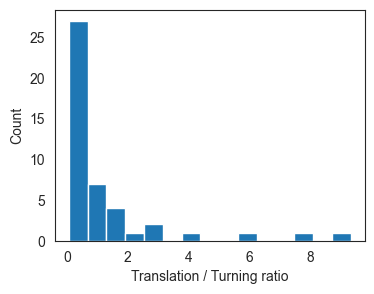

In [339]:
plt.figure(figsize=(4,3))
plt.hist(ratios, bins=15)
plt.xlabel("Translation / Turning ratio")
plt.ylabel("Count")
plt.show()